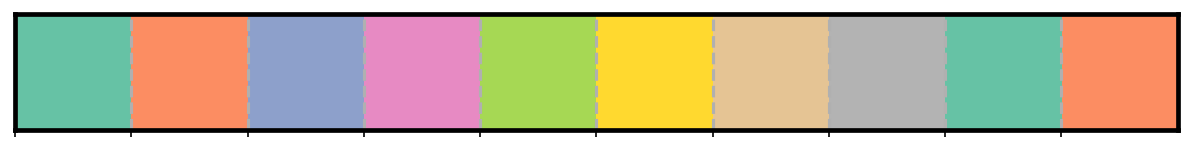

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy import stats
from iminuit import cost
from scipy import integrate
import scipy



def setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150):
    """
    Global plotting setup with grey background and custom styling
    """

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    # --- Background color ---
    plt.rcParams['axes.facecolor'] = "#e8e8e8"

    # --- Fonts ---
    rc = {"font.family": "serif", 
          "mathtext.fontset": "stix"}
    plt.rcParams.update(rc)
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
    
    plt.rcParams.update({
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Color palette ---
    colors = sns.color_palette("Set2", 10)
    sns.set_palette(colors)
    sns.palplot(colors)
    plt.show()

    return colors




def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
colors = setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150)

In [107]:
def likelihood(x, a, b):
    return (b**a) * (x**(a-1))  * np.exp(-b*x)/scipy.special.gamma(a)

def normalized_likelihood(x_vals, func, a, b, xrange=(0, 4)):
    norm_const, _ = integrate.quad(lambda x: func(x, a, b), xrange[0], xrange[1])
    return func(x_vals, a, b) / norm_const


    
def prior(x):
    x = np.asarray(x)
    result = np.zeros_like(x, dtype=float)
    N = (1.6 + 2.66 * 0.5) 
    result[(x > 0) & (x <= 1.6)] = 1.0/N
    result[(x > 1.6) & (x <= 2.1)] = 2.66/N
    return result

def posterior(x, a, b):
    likelihood_vals = likelihood(x, a, b)
    prior_vals = prior(x)
    unnormalized_posterior = likelihood_vals * prior_vals
    norm_const, _ = integrate.quad(lambda x: likelihood(x, a, b) * prior(x), 0, 4)
    return unnormalized_posterior / norm_const




Integral of prior over [0, 4]: 1.0000
Integral of posterior over [0, 4]: 1.0000
Integral of normalized likelihood over [0, 4]: 1.0000


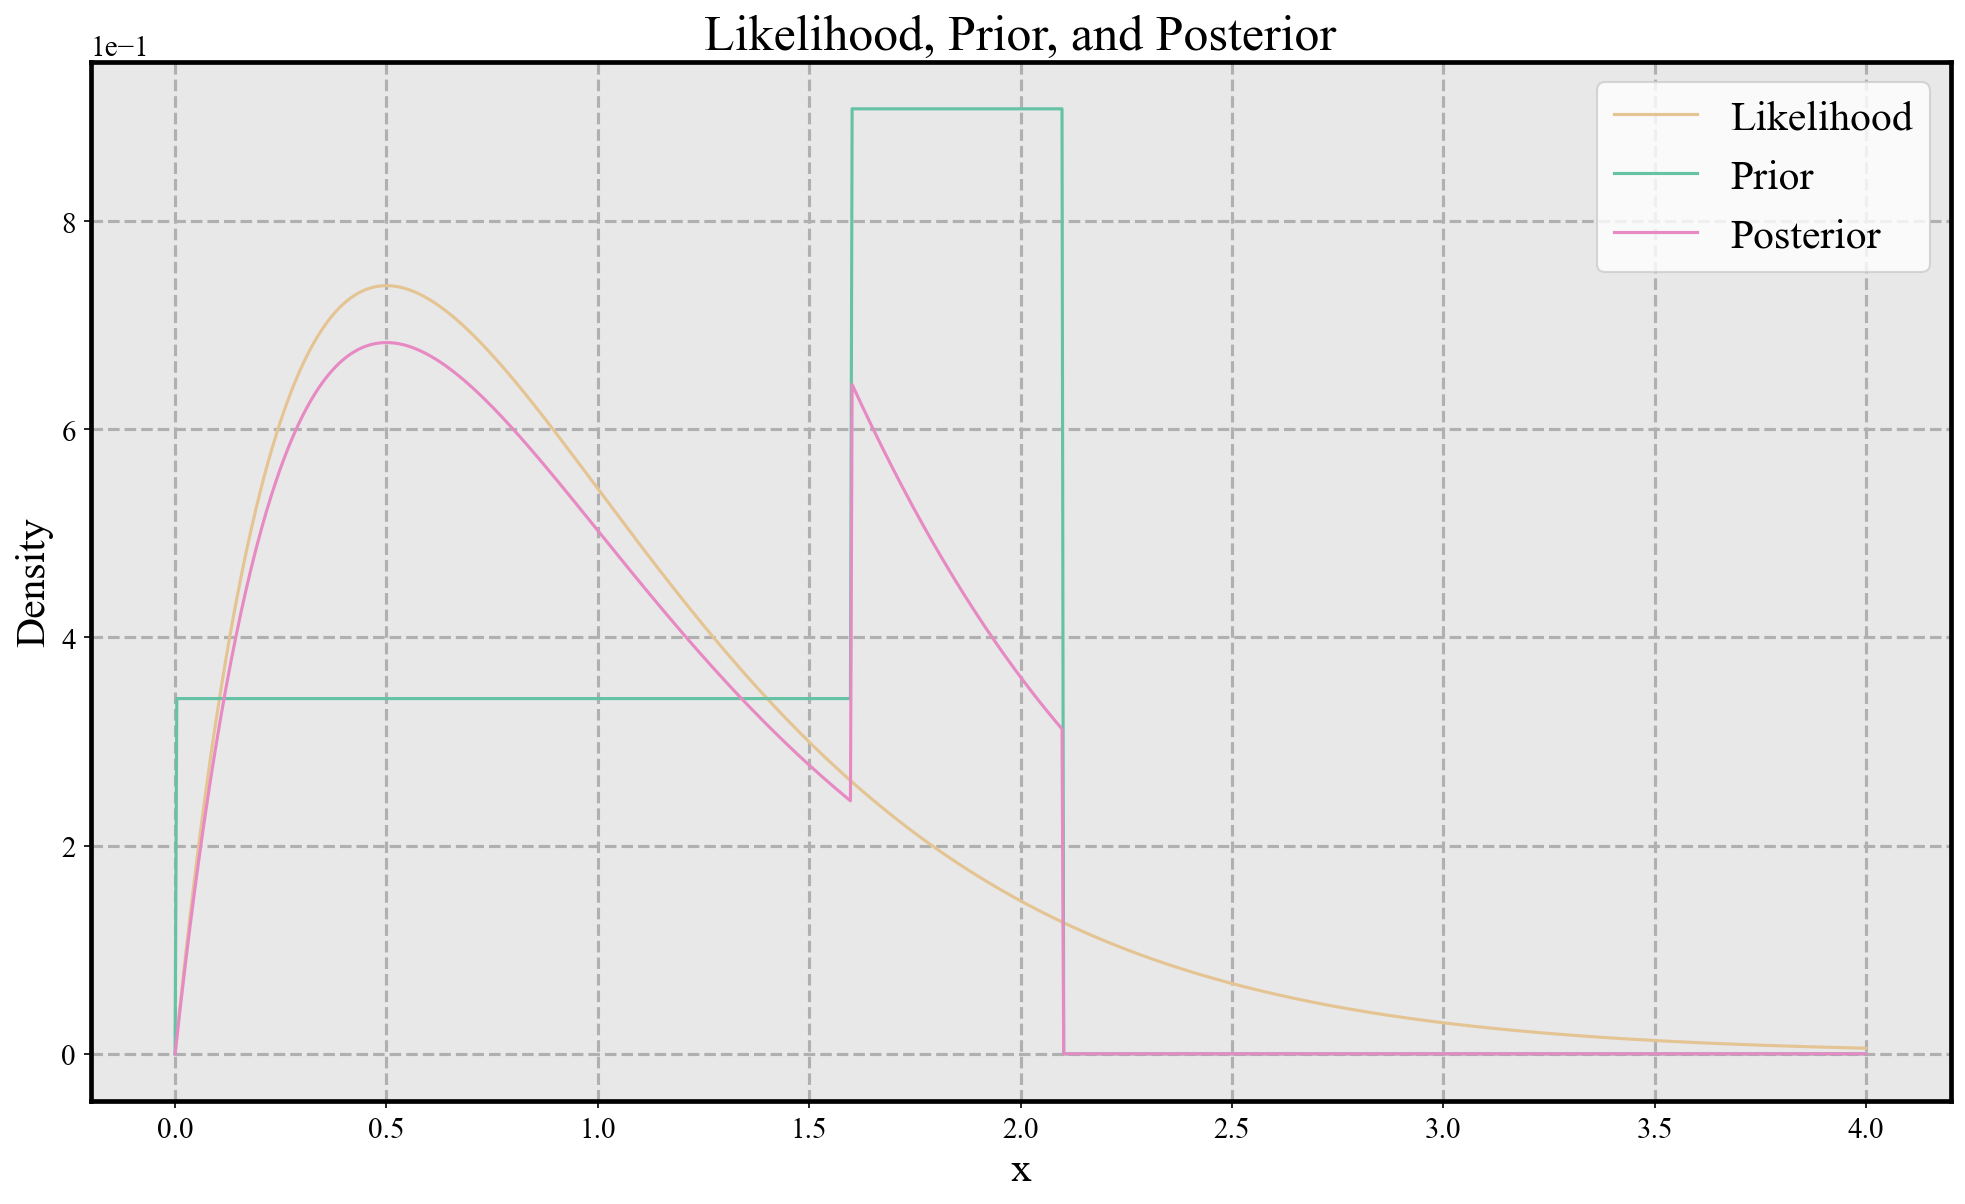

In [108]:
xrange=(0,4)
x_axis = np.linspace(xrange[0], xrange[1], 1000)
norm_like = normalized_likelihood(x_axis, likelihood, 2, 2, xrange=xrange)




integral_prior, _ = integrate.quad(lambda x: prior(x), xrange[0], xrange[1])
print(f"Integral of prior over [0, 4]: {integral_prior:.4f}")
norm_post, _ = integrate.quad(lambda x: posterior(x, 2, 2), xrange[0], xrange[1])
print(f"Integral of posterior over [0, 4]: {norm_post:.4f}")
norm_integral, _ = integrate.quad(lambda x: normalized_likelihood(x, likelihood, 2, 2, xrange=xrange), xrange[0], xrange[1])
print(f"Integral of normalized likelihood over [0, 4]: {norm_integral:.4f}")

plt.plot(x_axis, norm_like, color = colors[-4], label="Likelihood")
plt.plot(x_axis, prior(x_axis), color = colors[0], label="Prior")
plt.plot(x_axis, posterior(x_axis, 2, 2), color = colors[3], label="Posterior")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Likelihood, Prior, and Posterior")
plt.legend()
plt.show()


In [109]:
post = posterior(x_axis, 2, 2)
max_post = np.max(post)
max_values = x_axis[post == max_post]
print(f"Maximum of posterior: {max_post:.4f} at x = {max_values}")

Maximum of posterior: 0.6833 at x = [0.5005005]


In [110]:
(1.6 + 2.66 * 0.5) 

2.93